# Stokes-MHD relations

## 1. Prerrequisites

In [75]:
import sys
import numpy as np
sys.path.append("/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/utils/")
from pathlib import Path

from scipy.stats import pearsonr

from astropy.constants import c, e, m_e
from astropy import units as u

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

from muram_data import MhdData, StokesData

plt.rcParams.update({
  'axes.titlesize': 'x-large',  # heading 1
  'axes.labelsize': 'large',   # heading 2
  'xtick.labelsize': 'medium',         # fontsize of the ticks
  'ytick.labelsize': 'medium',         # fontsize of the ticks
  'font.family': 'serif',        # Font family
  'text.usetex': False,          # Do not use LaTeX for text rendering
  'figure.figsize': (10, 8),     # Default figure size
  'savefig.dpi': 300,            # High resolution for saving figures
  'savefig.format': 'png',       # Default format for saving figures
  'legend.fontsize': 'small',  # Font size for legends
  'lines.linewidth': 2,          # Line width for plots
  'lines.markersize': 8,         # Marker size for plots,
  'axes.formatter.useoffset': False,  # Disable offset
  'axes.formatter.use_mathtext': True,  # Use scientific notation
  'axes.formatter.limits': (-3, 4),  # Use scientific notation for values over 10^2
  'axes.labelsize': 'large',     # Font size for axes labels
  'figure.titlesize': 'xx-large', # Font size for suptitles (heading 1)
  'axes.formatter.use_locale': False  # Do not use locale settings
})



data_path = Path("/scratchsan/observatorio/juagudeloo/data/")
images_dir = Path("./notebooks_images/sample_step/")
step = 112

## 2. Charge data

### 2.1 MHD

Let's charge the sample step for the MHD data.

In [76]:
mhd = MhdData(
    data_path=data_path / "muram-simulation",
    nx=480, ny=480, nz=256
)

# Load a simulation step
mhd.load_step(step=step, z_max=250)

# Load opacity table and compute optical depth
mhd.load_opacity_table(kappa_path= data_path / "csv/kappa.0.dat")
mhd.compute_optical_depth(dz=1e6)

# Remap to optical depth coordinates
new_logtau = np.arange(-2.0, 0.1, 0.1)
mhd.remap_to_optical_depth(new_logtau, quantities=["T", "Vz", "Bz"])
print("MHD uploaded!")

Loading step 112000
  Trimmed z axis to first 250 layers (0..249)
  Reference layer (T ~ 5780 K) at z-index 186
  Done.
Opacity interpolator loaded from /scratchsan/observatorio/juagudeloo/data/csv/kappa.0.dat
  T range: [3.320, 5.300] (log10 K)
  P range: [-2.000, 8.000] (log10 dyne/cm²)
Computing optical depth...
  Optical depth computed.
Remapping to optical depth coordinates (21 levels)...
  Processing T
  Processing Vz
  Processing Bz
  Remapping complete.
MHD uploaded!


### 2.2 Stokes

Let's charge the stokes data for the sample step.

In [77]:
# Initialize
stokes = StokesData(
    data_dir=data_path / "muram-simulation/",
    step=step,
    wavelength_range=(6300.5, 6303.5),
    wavelength_step=0.01
)

# Load Stokes cube
stokes.load_stokes()
stokes.continuum_normalization(cont_indices=[0, 1, 2, 3])
stokes.load_hinode_lsf(data_path / "hinode-MODEST/PSFs/hinode_sp.spline.psf")
stokes.apply_spectral_convolution()
stokes.resample_to_hinode()
#stokes.add_hinode_noise(noise_level=5.9e-4)
print("Stokes uploaded!")

Loading Stokes data from /scratchsan/observatorio/juagudeloo/data/muram-simulation/stokes_112000.npy


  I shape: (480, 480, 300)
  Q shape: (480, 480, 300)
  U shape: (480, 480, 300)
  V shape: (480, 480, 300)
  Done.
Applying continuum normalization...
  Global continuum: I_c = 2.703507e+14
  Done.
Loading Hinode LSF from /scratchsan/observatorio/juagudeloo/data/hinode-MODEST/PSFs/hinode_sp.spline.psf
  LSF wavelength range: -0.060 - 0.060 Å
  LSF kernel size: 13
  Done.
Applying spectral convolution with LSF...
  I: convolved
  Q: convolved
  U: convolved
  V: convolved
  Done.
Resampling to Hinode/SP wavelengths...
  112 wavelength points from 6300.7960 to 6303.1825 Å
  I: resampled to shape (480, 480, 112)
  Q: resampled to shape (480, 480, 112)
  U: resampled to shape (480, 480, 112)
  V: resampled to shape (480, 480, 112)
  Done.
Stokes uploaded!


## 3. Stokes inversions

For the calculations below we are going to assume the absorption line of FeI centered at $\lambda_0 = 6301.5\,\text{\AA}$.

In [78]:
llambda0 = 6301.5*u.Angstrom  # central wavelength in Angstroms
g_lande = 1.67  # effective Landé factor for Fe I 6301.5 Å

In [93]:
def compare_approx_with_heights(approx_q, muram_q_data, logtau_values,
                                quantity_name:str = "",
                                figsize=(14, 6),):
    """
    Compare aproximated quantity with the MURaM quantity at each height (logtau level) using RRMSE and Pearson correlation.
    
    Args:
    approx_q: numpy.ndarray
        2D map of the approximated quantity
    muram_q_data: numpy.ndarray
        3D data cube of the MURaM quantity with shape (nx, ny, nz) where nz corresponds to logtau levels
    logtau_values: numpy.ndarray
        Array of logtau values corresponding to the third axis of muram_q_data
    figsize: tuple
        Figure size for the comparison plots
    """
    
    nz = muram_q_data.shape[2]
    rrmse_values = []
    correlation_values = []
    
    # Calculate RRMSE and Pearson correlation for each height
    for k in range(nz):
        muram_q_k = muram_q_data[:, :, k]
        rmse = np.sqrt(np.mean((approx_q - muram_q_k)**2))
        rrmse = rmse / np.mean(np.abs(muram_q_k))
        rrmse_values.append(rrmse)
        
        # Pearson correlation
        corr, _ = pearsonr(approx_q.flatten(), muram_q_k.flatten())
        correlation_values.append(corr)
    
    # Plot RRMSE and correlation vs optical depth
    fig, ax = plt.subplots(1, 2, figsize=(14, 6))
    
    ax[0].plot(logtau_values, rrmse_values, marker='o', linewidth=2, markersize=8, color='C0')
    ax[0].set_xlabel('log τ')
    ax[0].set_ylabel('RRMSE')
    ax[0].set_title('Relative Root Mean Square Error vs Optical Depth')
    ax[0].grid(True, alpha=0.3)
    
    ax[1].plot(logtau_values, correlation_values, marker='s', linewidth=2, markersize=8, color='C1')
    ax[1].set_xlabel('log τ')
    ax[1].set_ylabel('Pearson Correlation')
    ax[1].set_title('Pearson Correlation vs Optical Depth')
    ax[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Find the height with lowest RRMSE and highest correlation
    min_rrmse_idx = np.argmin(rrmse_values)
    max_corr_idx = np.argmax(correlation_values)
    min_logtau_rrmse = logtau_values[min_rrmse_idx]
    min_rrmse = rrmse_values[min_rrmse_idx]
    max_logtau_corr = logtau_values[max_corr_idx]
    max_corr = correlation_values[max_corr_idx]
    
    # Plot comparison at the height with lowest RRMSE and highest correlation
    fig, ax = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(f'{quantity_name} comparison: Lowest RRMSE at log τ = {min_logtau_rrmse:.2f} | Highest correlation at log τ = {max_logtau_corr:.2f}', fontsize='x-large')
    
    # WFA B_LOS map
    im_wfa = ax[0].imshow(approx_q, origin='lower', cmap='RdBu_r')
    ax[0].set_title(f'WFA {quantity_name} Map')
    ax[0].set_xticks([])
    ax[0].set_yticks([])
    divider_wfa = make_axes_locatable(ax[0])
    cax_wfa = divider_wfa.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(im_wfa, cax=cax_wfa, label=f'{quantity_name} (G)')
    
    # MHD B_z at lowest RRMSE
    im0 = ax[1].imshow(muram_q_data[:, :, min_rrmse_idx], origin='lower', cmap='RdBu_r')
    ax[1].set_title(f'MURaM {quantity_name} at log τ = {min_logtau_rrmse:.2f} \n (RRMSE = {min_rrmse:.4f})')
    ax[1].set_xticks([])
    ax[1].set_yticks([])
    divider0 = make_axes_locatable(ax[1])
    cax0 = divider0.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(im0, cax=cax0, label=f'{quantity_name} (G)')
    
    # MHD B_z at highest correlation
    im1 = ax[2].imshow(muram_q_data[:, :, max_corr_idx], origin='lower', cmap='RdBu_r')
    ax[2].set_title(f'MURaM {quantity_name} at log τ = {max_logtau_corr:.2f} \n (Correlation = {max_corr:.4f})')
    ax[2].set_xticks([])
    ax[2].set_yticks([])
    divider1 = make_axes_locatable(ax[2])
    cax1 = divider1.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(im1, cax=cax1, label=f'{quantity_name} (G)')

    
    plt.tight_layout()
    plt.show()


### 3.1 $B_\text{LOS}$ with WFA

We will define a function for applying a fit for an overdetermined system using the WFA that follows
\begin{equation}
    V \approx -\frac{e}{4\pi m_e c} \cdot \lambda_0^2 \cdot g_{\lambda_0} \cdot B_{\text{LOS}} \frac{dI}{dl}
\end{equation}


In [80]:
def B_LOS_WFA(stokes:dict[str, np.ndarray],
                      ll:np.ndarray,
                      wl_blos_range:list[int],
                      llambda0:float,
                      g:float):
    """
    Estimate the line-of-sight magnetic field from a data cube of Stokes I profiles.
    Args:
    stokes: numpy.ndarray
        3D data cube of Stokes I profiles
    ll: numpy.ndarray
        Wavelength axis in amstrongs
    start_ll: int
        Index of the starting wavelength range
    end_ll: int
        Index of the ending wavelength range
    llambda0: float
        Rest wavelength in amstrongs
    g: float
        Landé factor
    stokes_v_index: int
        Index of the Stokes V profile in the data cube
    Returns:
    numpy.ndarray
        2D map of the line-of-sight magnetic field in Gauss
    """
    wfa_constant = e.si / (4 * np.pi) / m_e / c
    wfa_constant = wfa_constant.to(1 / u.G / u.Angstrom )
    def estimate_B(dI_dl, V):
        ND = len(V)
        a = np.zeros([ND, 2])
        a[:, 0] = dI_dl[:]
        a[:, 1] = 1.0
        b = V[:]

        # Correct least-squares solution
        p = np.linalg.pinv(a) @ b / dI_dl.unit
        
        # Compute B_LOS
        B = -p[0]*u.Angstrom / (wfa_constant * (llambda0)**2.0 * g)
        return B
        
    NX = stokes["I"].shape[0]
    NY = stokes["I"].shape[1]

    B = np.zeros([NX,NY])

    for i in range (0,NX):
        for j in range(0,NY):
            dI_dl =  np.gradient(stokes["I"][i,j,wl_blos_range[0]:wl_blos_range[1]]) / np.gradient(ll[wl_blos_range[0]:wl_blos_range[1]])
            local_B = estimate_B(dI_dl = dI_dl,
                                V = stokes["V"][i,j,wl_blos_range[0]:wl_blos_range[1]])
            B[i,j] = local_B.value
    B = B * u.G
    
    return B

Let's check the range of the stokes spectra that is useful for calculating the $B_\text{LOS}$

stokes shape (480, 480, 112)
wl shape (112,)


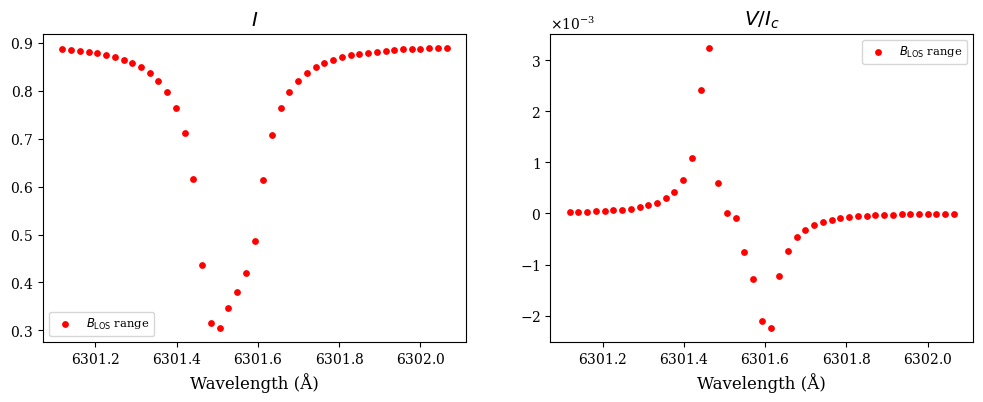

In [81]:
wl_blos_range = [15,60]

# Plot blos wavelength range for profiles.
fig, ax = plt.subplots(1,2, figsize=(12,4))
test_x = 358
test_y = 380
stokes.plot_stokes(ax=ax, x=test_x, y=test_y, wl_index_range = wl_blos_range,scatter=True, color="red", s=15, label=r"$B_\text{LOS}$ range")
plt.show()

In [82]:
blos_wfa = B_LOS_WFA(stokes = stokes.data, 
                                   ll = stokes.wl*u.Angstrom, 
                                   wl_blos_range = wl_blos_range,
                                   llambda0 = llambda0, 
                                   g = g_lande)

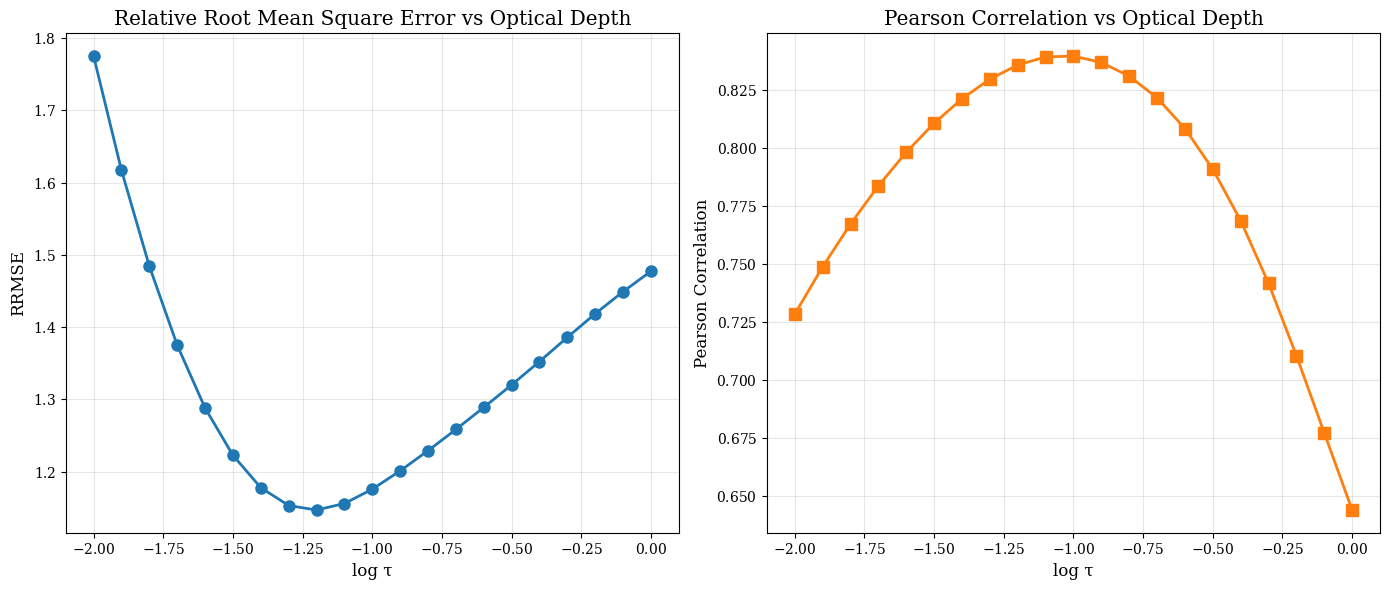

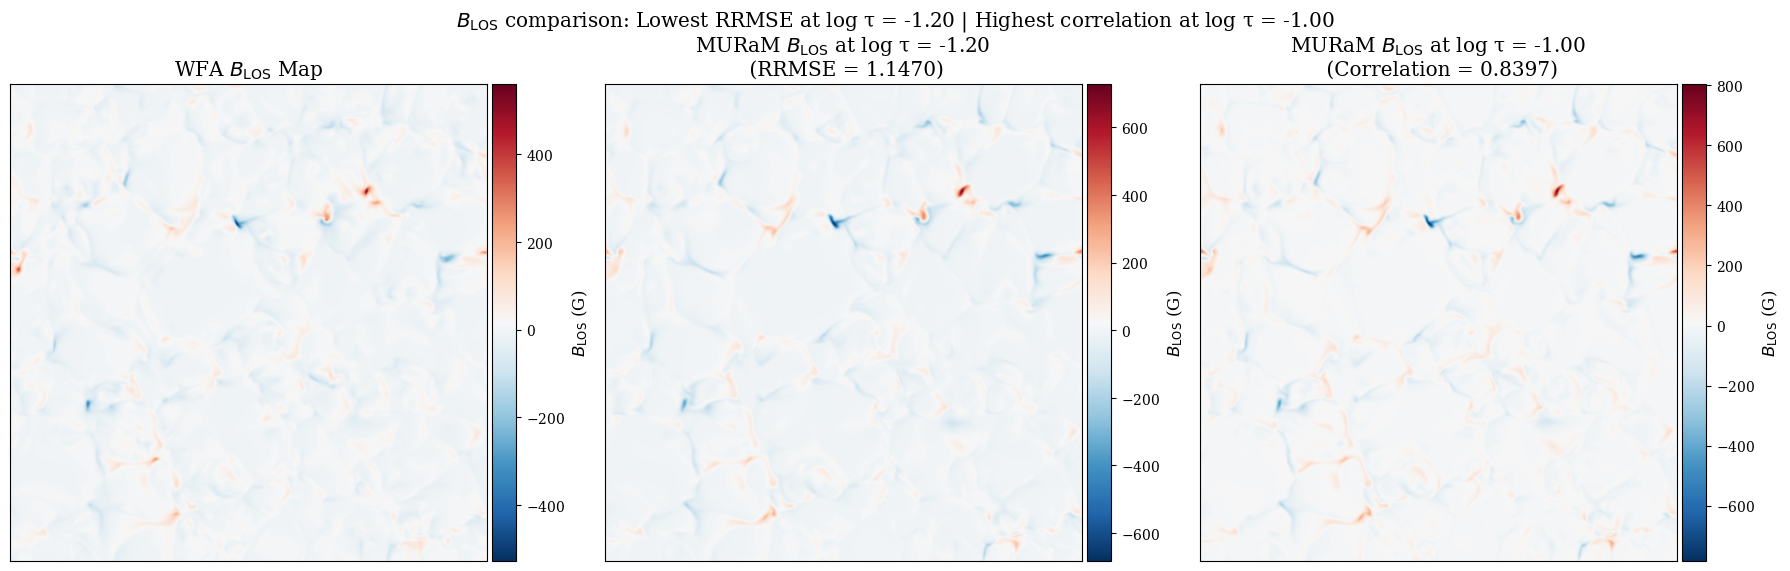

In [94]:
# Run the comparison
compare_approx_with_heights(blos_wfa.value, mhd.od_data["Bz"], new_logtau, quantity_name = r"$B_\text{LOS}$")

### 3.2 $v_\text{LOS}$ with zero-refference velocity

For the calculation of the $v_\text{LOS}$ we are going to use the Doppler formula
\begin{equation}
    v_\text{LOS} = \frac{\Delta \lambda}{\lambda_0} c
\end{equation}

In [84]:
def vlos_doppler(stokes:dict[str, np.ndarray],
                      ll:np.ndarray,
                      wl_blos_range:list[int],
                      llambda0:float):
    
    center_range = np.stack([
                    np.argmin(np.abs(stokes.data["V"][:, :, wl_blos_range[0]:wl_blos_range[1]]), axis=2),
                    np.argmax(np.abs(stokes.data["V"][:, :, wl_blos_range[0]:wl_blos_range[1]]), axis=2)
                    ], axis=-1)
    
    vlos_map = np.zeros(center_range.shape[0:2])

    for ix in range(center_range.shape[0]):
        for iy in range(center_range.shape[1]):
            if center_range[ix, iy, 0] > center_range[ix, iy, 1]:
                right_llambda_pos = center_range[ix, iy, 0]
                left_llambda_pos = center_range[ix, iy, 1]
            else:
                right_llambda_pos = center_range[ix, iy, 1]
                left_llambda_pos = center_range[ix, iy, 0]
            
            llambda_interpol = np.interp(0, stokes.data["V"][ix,iy,left_llambda_pos:right_llambda_pos][::-1], ll[left_llambda_pos:right_llambda_pos][::-1])
            vlos_map[ix, iy] = (c.to(u.km/u.s) * ((llambda_interpol - llambda0.to(u.Angstrom)) / llambda0.to(u.Angstrom))).value
    
    return vlos_map * u.km / u.s
    

In [85]:
vlos_dop = vlos_doppler(stokes = stokes, 
                ll = stokes.wl*u.Angstrom, 
                wl_blos_range = wl_blos_range,
                llambda0 = llambda0)

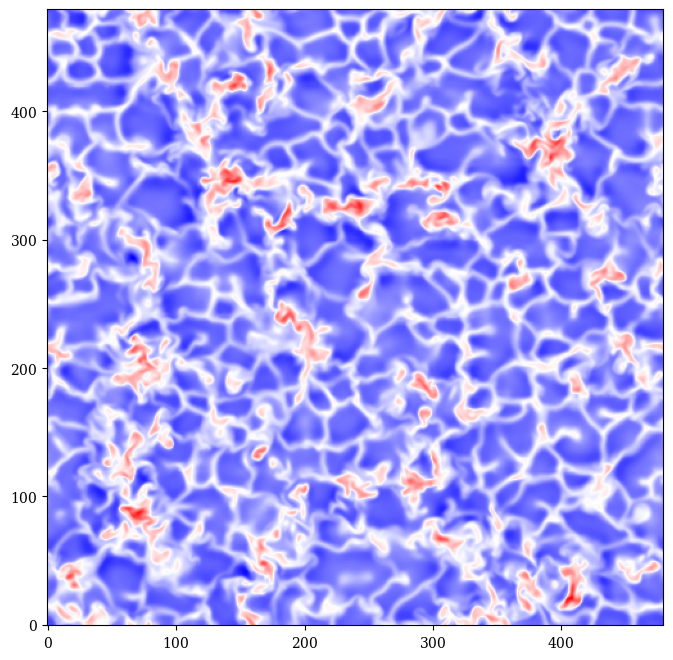

In [103]:
plt.imshow(mhd.data["Vz"][:, :, 20], origin='lower', cmap='bwr_r')

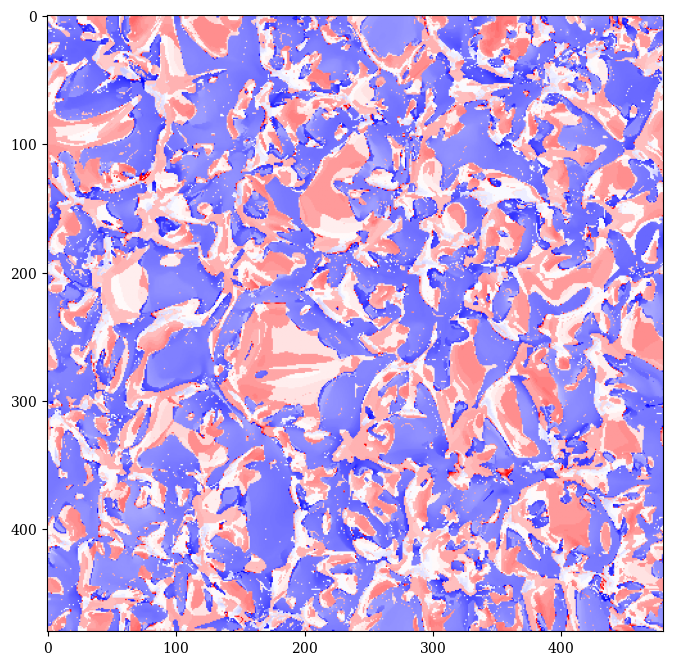

In [104]:
plt.imshow(vlos_dop.value, cmap='bwr_r')